# Price Prediction

This notebook prepares a modelling-ready dataset from the warehouse, compares several regression approaches, and explains which features matter most for price prediction. The emphasis is on both predictive performance and business interpretability.

In [1]:
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
con = duckdb.connect("../data/warehouse.duckdb", read_only=True)
print("Connected:", con.execute("SELECT COUNT(*) FROM fact_listing_performance").fetchone())

Connected: (15293,)


In [2]:
# Pull all relevant features from warehouse
raw = con.execute("""
    SELECT 
        f.listing_id,
        f.price,
        -- Target and basic listing features
        l.room_type,
        l.property_type,
        l.accommodates,
        l.bathrooms,
        l.bedrooms,
        l.beds,
        l.neighbourhood_name,
        n.neighbourhood_group,
        -- Host features
        h.host_is_superhost,
        h.host_listings_count,
        h.hosts_time_as_host_years,
        -- Performance features (careful: no leakage from target)
        f.number_of_reviews,
        f.review_scores_rating,
        f.review_scores_cleanliness,
        f.review_scores_location,
        f.review_scores_value,
        f.availability_365,
        f.minimum_nights,
        f.estimated_occupancy_l365d,
        -- Demand segment
        v.demand_segment
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    JOIN dim_neighbourhood n ON l.neighbourhood_name = n.neighbourhood_name
    JOIN dim_host h ON l.host_id = h.host_id
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    WHERE f.price IS NOT NULL 
      AND l.price_is_valid
      AND v.demand_segment = 'active'
""").df()

print(f"Raw shape: {raw.shape}")
print(f"Price stats:\n{raw['price'].describe()}")
print(f"\nNull counts:\n{raw.isnull().sum().sort_values(ascending=False).head(15)}")

Raw shape: (9174, 22)
Price stats:
count    9174.000000
mean      234.332086
std       185.428692
min        11.060000
25%       109.857500
50%       213.675000
75%       303.000000
max      4463.000000
Name: price, dtype: float64

Null counts:
bathrooms                   1104
bedrooms                     835
beds                         489
host_listings_count           50
host_is_superhost             50
hosts_time_as_host_years      50
minimum_nights                 1
accommodates                   0
room_type                      0
price                          0
listing_id                     0
property_type                  0
neighbourhood_group            0
neighbourhood_name             0
number_of_reviews              0
dtype: int64


## Feature Engineering and Data Preparation

The next cells create a supervised learning dataset by combining listing attributes, host characteristics, and demand measures from the warehouse. A small amount of feature engineering is applied here so the model can capture signals such as capacity, room type, and listing quality.

In [4]:

df = raw.copy()

# 1. Target: log-transform price (reduces right-skew for linear models,
#    makes residuals more interpretable; we'll inverse-transform for metrics)
df['log_price'] = np.log1p(df['price'])

# 2. Feature: price_per_person
df['price_per_person'] = df['price'] / df['accommodates'].clip(lower=1)

# 3. Feature: beds_per_person
df['beds_per_person'] = df['beds'] / df['accommodates'].clip(lower=1)

# 4. Binary encode superhost
df['is_superhost'] = (df['host_is_superhost'] == 't').astype(int)

# 5. Binary: has review score
df['has_rating'] = df['review_scores_rating'].notna().astype(int)

# 6. Fill review score nulls with 0 (separate has_rating flag carries the info)
for col in ['review_scores_rating', 'review_scores_cleanliness',
            'review_scores_location', 'review_scores_value']:
    df[col] = df[col].fillna(0)

# 7. Median impute numeric nulls FIRST
for col in ['bathrooms', 'bedrooms', 'beds', 'host_listings_count',
            'hosts_time_as_host_years', 'minimum_nights']:
    df[col] = df[col].fillna(df[col].median())

# 7b. Derived features AFTER imputation (no null inheritance)
df['beds_per_person'] = df['beds'] / df['accommodates'].clip(lower=1)

# 8. Encode categoricals
df['room_type_enc'] = df['room_type'].map({
    'Entire home/apt': 3,
    'Private room': 2,
    'Hotel room': 1,
    'Shared room': 0
})

# One-hot encode neighbourhood_group (10 groups)
neighbourhood_dummies = pd.get_dummies(df['neighbourhood_group'], prefix='ng', drop_first=True)
df = pd.concat([df, neighbourhood_dummies], axis=1)

# Define feature columns
feature_cols = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'room_type_enc', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'estimated_occupancy_l365d', 'host_listings_count',
    'hosts_time_as_host_years', 'is_superhost', 'has_rating',
    'beds_per_person'
] + list(neighbourhood_dummies.columns)

X = df[feature_cols].astype(float)
y = df['log_price']
y_raw = df['price']

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_cols}")
print(f"Any remaining nulls: {X.isnull().sum().sum()}")

Feature matrix shape: (9174, 27)
Features: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'room_type_enc', 'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'estimated_occupancy_l365d', 'host_listings_count', 'hosts_time_as_host_years', 'is_superhost', 'has_rating', 'beds_per_person', 'ng_Eixample', 'ng_Gràcia', 'ng_Horta-Guinardó', 'ng_Les Corts', 'ng_Nou Barris', 'ng_Sant Andreu', 'ng_Sant Martí', 'ng_Sants-Montjuïc', 'ng_Sarrià-Sant Gervasi']
Any remaining nulls: 0


In [5]:
import time

from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate
from xgboost import XGBRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae_original_scale(y_true, y_pred):
    """MAE on original price scale (inverse log transform)"""
    return mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))

def rmse_original_scale(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

models = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10.0))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    cv = cross_validate(
        model, X, y,
        cv=kf,
        scoring={
            'r2': 'r2',
            'neg_mae': make_scorer(mae_original_scale, greater_is_better=False),
            'neg_rmse': make_scorer(rmse_original_scale, greater_is_better=False)
        },
        return_train_score=True
    )
    elapsed = time.time() - start
    results[name] = {
        'R²': cv['test_r2'].mean(),
        'R² std': cv['test_r2'].std(),
        'MAE (EUR)': -cv['test_neg_mae'].mean(),
        'RMSE (EUR)': -cv['test_neg_rmse'].mean(),
        'Train R²': cv['train_r2'].mean(),
        'Time (s)': elapsed
    }
    print(f"  Done in {elapsed:.1f}s — R²={results[name]['R²']:.3f}, MAE=€{results[name]['MAE (EUR)']:.2f}")

results_df = pd.DataFrame(results).T
print(f"\n{'='*70}")
print("MODEL COMPARISON (5-fold cross-validation)")
print('='*70)
print(results_df.round(3).to_string())

Training Ridge Regression...
  Done in 0.2s — R²=0.805, MAE=€57.13
Training Random Forest...
  Done in 8.7s — R²=0.845, MAE=€52.48
Training XGBoost...
  Done in 4.4s — R²=0.857, MAE=€50.36

MODEL COMPARISON (5-fold cross-validation)
                     R²  R² std  MAE (EUR)  RMSE (EUR)  Train R²  Time (s)
Ridge Regression  0.805   0.016     57.128     115.495     0.808     0.172
Random Forest     0.845   0.012     52.478     110.635     0.913     8.732
XGBoost           0.857   0.014     50.356     106.862     0.940     4.382


## Model Training and Comparison

This section compares several regression models using cross-validation so the final choice is based on out-of-sample performance rather than a single train split. The goal is to identify the model that best balances accuracy, stability, and interpretability for downstream pricing use cases.

Final model fitted on full dataset
Computing SHAP values...
SHAP values shape: (9174, 27)


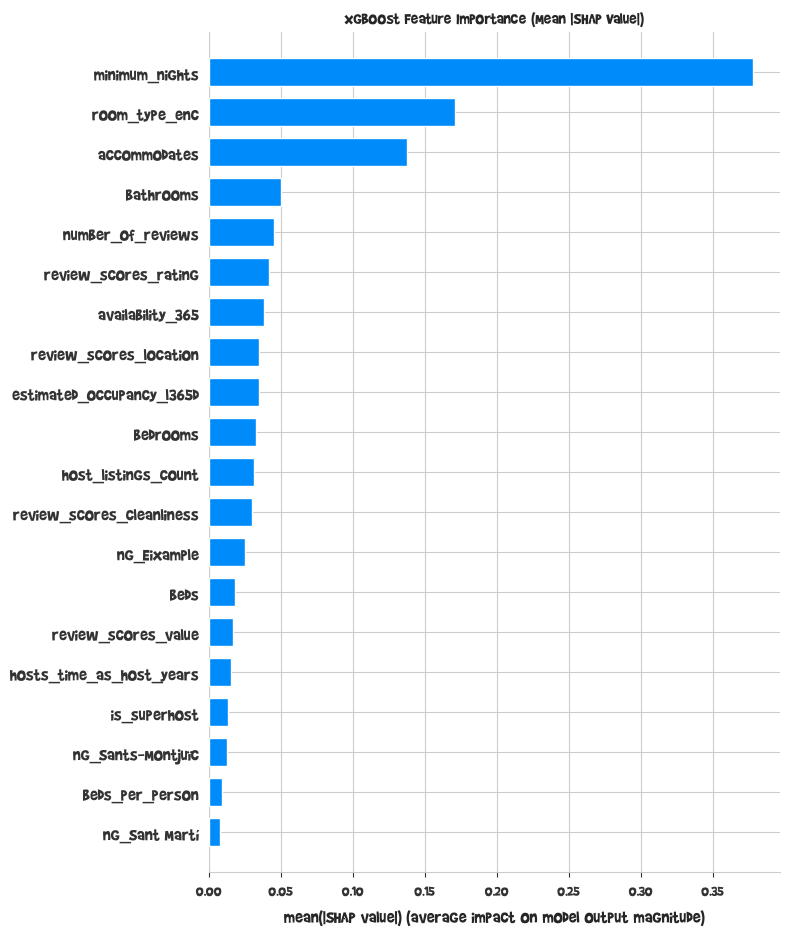

SHAP importance plot saved


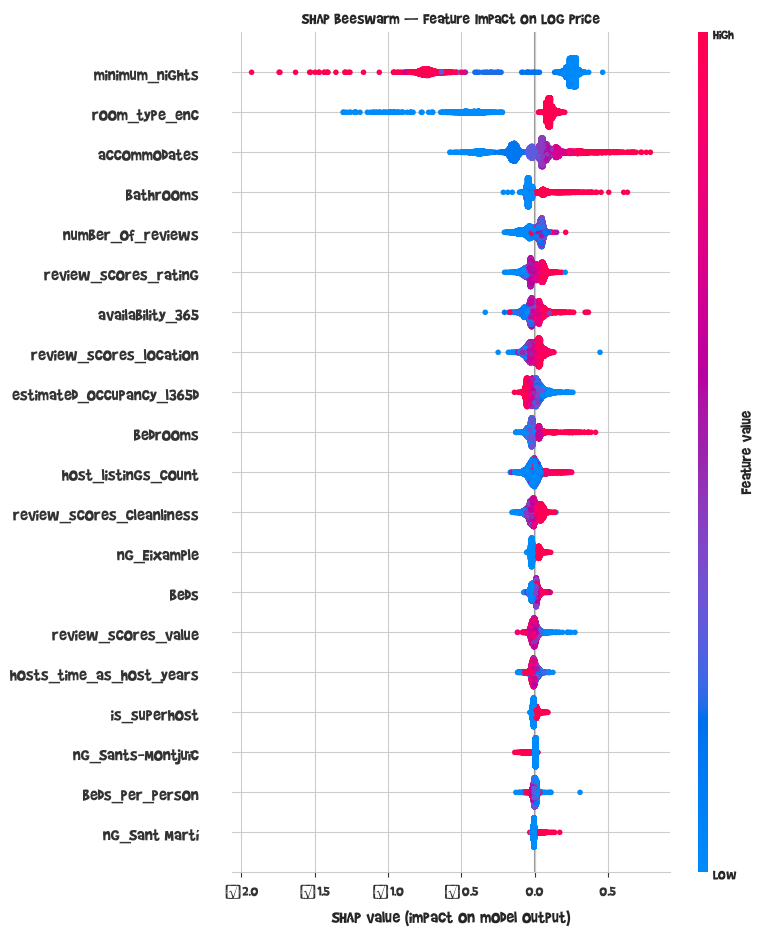

SHAP beeswarm plot saved


In [6]:
# Fit final model on full dataset for SHAP analysis
final_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
final_model.fit(X, y)
print("Final model fitted on full dataset")

# SHAP explainability
print("Computing SHAP values...")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)
print(f"SHAP values shape: {shap_values.shape}")

# Summary plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.title("XGBoost Feature Importance (Mean |SHAP Value|)")
plt.tight_layout()
plt.savefig("../reports/figures/shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP importance plot saved")

# Beeswarm plot — shows direction of impact too
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values, X,
    feature_names=feature_cols,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Log Price")
plt.tight_layout()
plt.savefig("../reports/figures/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP beeswarm plot saved")

In [7]:
# Get numerical SHAP importance ranking
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Feature importance by mean |SHAP value| (log price scale):")
print(shap_importance.to_string(index=False))

Feature importance by mean |SHAP value| (log price scale):
                  feature  mean_abs_shap
           minimum_nights       0.377880
            room_type_enc       0.171085
             accommodates       0.137970
                bathrooms       0.049927
        number_of_reviews       0.045414
     review_scores_rating       0.042019
         availability_365       0.038384
   review_scores_location       0.034941
estimated_occupancy_l365d       0.034702
                 bedrooms       0.033002
      host_listings_count       0.031156
review_scores_cleanliness       0.030219
              ng_Eixample       0.025231
                     beds       0.018008
      review_scores_value       0.016943
 hosts_time_as_host_years       0.015743
             is_superhost       0.013268
        ng_Sants-Montjuïc       0.012525
          beds_per_person       0.008962
            ng_Sant Martí       0.007733
           ng_Sant Andreu       0.002913
                ng_Gràcia       0.00256

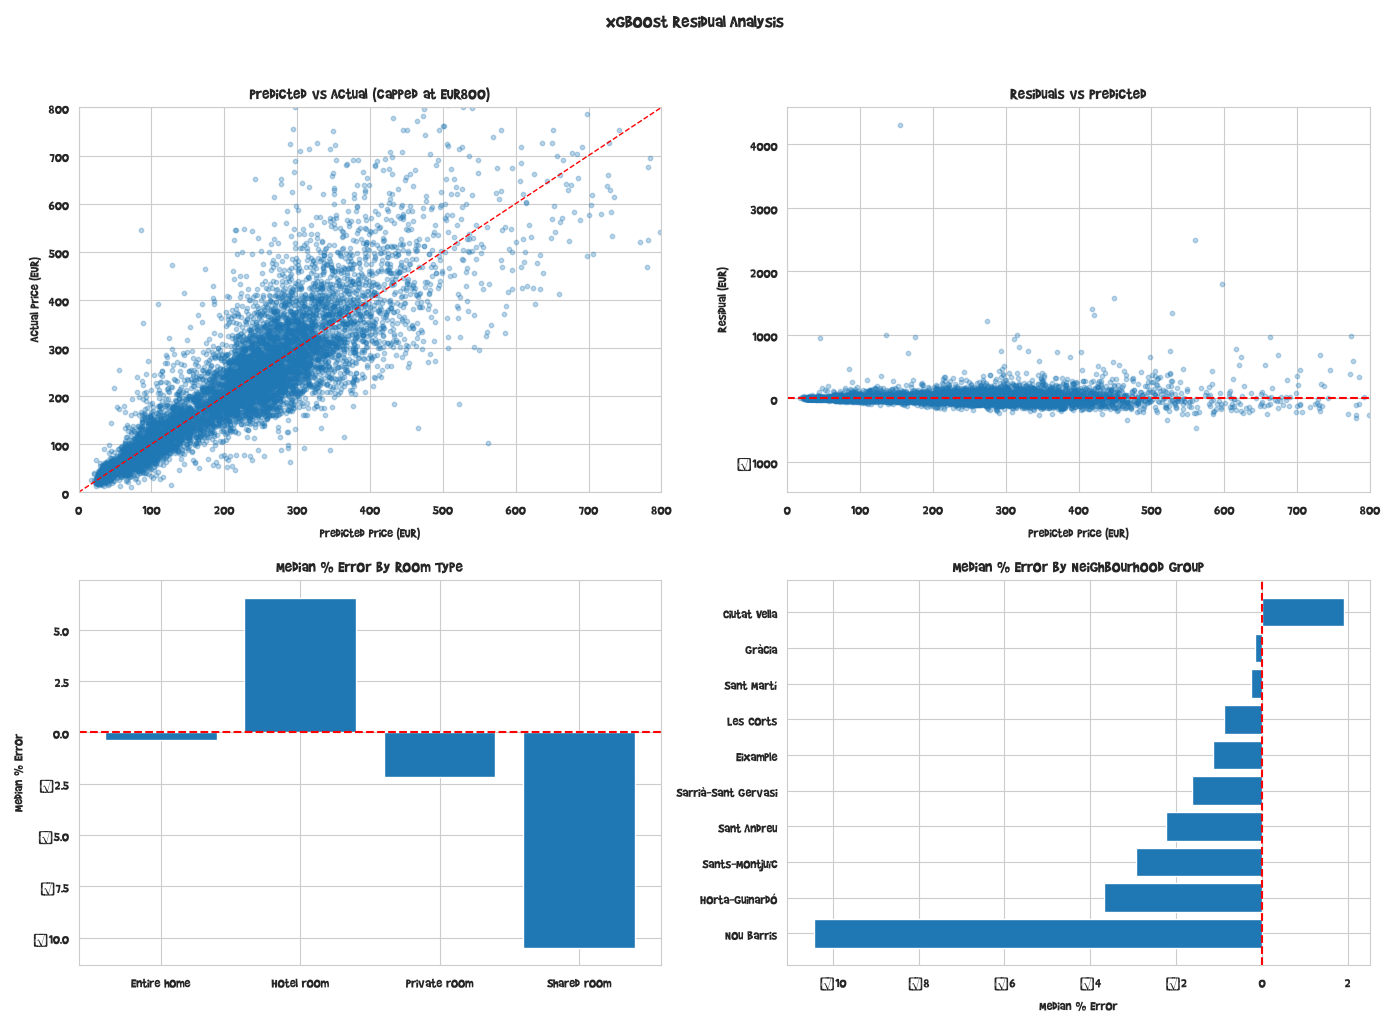


Median % error by room type:
                 median   mean    std
room_type_label                      
Entire home       -0.37  -3.73  32.22
Hotel room         6.55   5.88  20.58
Private room      -2.19  -6.09  35.00
Shared room      -10.49 -14.10  39.42

Median % error by neighbourhood group:
                     median   mean    std
neighbourhood_group                      
Ciutat Vella           1.90  -3.34  34.98
Eixample              -1.15  -3.76  29.47
Gràcia                -0.16  -4.09  29.70
Horta-Guinardó        -3.67  -8.62  50.47
Les Corts             -0.88  -5.82  31.13
Nou Barris           -10.45 -15.51  52.43
Sant Andreu           -2.24  -6.42  25.27
Sant Martí            -0.25  -4.50  43.01
Sants-Montjuïc        -2.94  -4.71  27.89
Sarrià-Sant Gervasi   -1.64  -4.91  30.51


In [8]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predictions for honest residual analysis
y_pred_log = cross_val_predict(final_model, X, y, cv=kf)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y)

residuals = y_actual - y_pred
pct_error = (residuals / y_actual) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual
axes[0,0].scatter(y_pred, y_actual, alpha=0.3, s=10)
axes[0,0].plot([0, 800], [0, 800], 'r--', linewidth=1)
axes[0,0].set_xlim(0, 800)
axes[0,0].set_ylim(0, 800)
axes[0,0].set_xlabel("Predicted Price (EUR)")
axes[0,0].set_ylabel("Actual Price (EUR)")
axes[0,0].set_title("Predicted vs Actual (capped at EUR800)")

# 2. Residuals vs Predicted
axes[0,1].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[0,1].axhline(0, color='r', linestyle='--')
axes[0,1].set_xlim(0, 800)
axes[0,1].set_xlabel("Predicted Price (EUR)")
axes[0,1].set_ylabel("Residual (EUR)")
axes[0,1].set_title("Residuals vs Predicted")

# 3. Residuals by room type
room_type_map = {3: 'Entire home', 2: 'Private room', 1: 'Hotel room', 0: 'Shared room'}
df['room_type_label'] = df['room_type_enc'].map(room_type_map)
df['residual'] = residuals.values
df['pct_error'] = pct_error.values

room_residuals = df.groupby('room_type_label')['pct_error'].median()
axes[1,0].bar(room_residuals.index, room_residuals.values)
axes[1,0].axhline(0, color='r', linestyle='--')
axes[1,0].set_title("Median % Error by Room Type")
axes[1,0].set_ylabel("Median % Error")

# 4. Residuals by neighbourhood group
ng_residuals = df.groupby('neighbourhood_group')['pct_error'].median().sort_values()
axes[1,1].barh(ng_residuals.index, ng_residuals.values)
axes[1,1].axvline(0, color='r', linestyle='--')
axes[1,1].set_title("Median % Error by Neighbourhood Group")
axes[1,1].set_xlabel("Median % Error")

plt.suptitle("XGBoost Residual Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/residual_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nMedian % error by room type:")
print(df.groupby('room_type_label')['pct_error'].agg(['median','mean','std']).round(2))
print("\nMedian % error by neighbourhood group:")
print(df.groupby('neighbourhood_group')['pct_error'].agg(['median','mean','std']).round(2))

## Save Model Artefacts

Serialise the fitted XGBoost model, its SHAP explainer, and all feature-engineering
metadata (column list, imputation medians, encoding maps) to `models/` so the
Streamlit dashboard can load them without re-training.

In [ ]:
# ── Save Model Artefacts ────────────────────────────────────────────────
# Serialise the final XGBoost model, SHAP explainer, and all metadata
# so the Streamlit dashboard can load them without re-training.
import os

import joblib

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Final model (trained on full dataset in the cell above)
joblib.dump(final_model, os.path.join(MODELS_DIR, "xgboost_model.joblib"))

# SHAP explainer
joblib.dump(explainer, os.path.join(MODELS_DIR, "shap_explainer.joblib"))

# Imputation medians (computed on the training dataframe `df`)
IMPUTE_COLS = ['bathrooms', 'bedrooms', 'beds', 'host_listings_count',
               'hosts_time_as_host_years', 'minimum_nights']
medians = {col: float(df[col].median()) for col in IMPUTE_COLS}

# Metadata bundle
meta = {
    'feature_cols':  feature_cols,
    'ng_dummy_cols': list(neighbourhood_dummies.columns),
    'medians':       medians,
    'room_type_enc': {
        'Entire home/apt': 3,
        'Private room':    2,
        'Hotel room':      1,
        'Shared room':     0,
    },
}
joblib.dump(meta, os.path.join(MODELS_DIR, "model_meta.joblib"))

print('✅  Model artefacts saved:')
for f in sorted(os.listdir(MODELS_DIR)):
    size_kb = os.path.getsize(os.path.join(MODELS_DIR, f)) // 1024
    print(f'   {f:<35}  {size_kb:>5} KB')
